# НИС «Основы анализа данных в Python»

*Алла Тамбовцева, НИУ ВШЭ*

## Предварительная обработка текста и построение облака слов

### Подготовка к работе

В этом практикуме мы будем работать с текстом, в частности, построим на основе текста облако слов (*word cloud*), которое показывает, какие слова встречаются в тексте чаще, а какие – реже.

Установим необходимые библиотеки:

* библиотека `wordcloud` для построения облака слов ([тьюториал](https://www.datacamp.com/tutorial/wordcloud-python) по работе с библиотекой);
* библиотека `pymorphy3` для морфологического анализа текстов, понадобится для приведения слов к начальной форме ([документация](https://pymorphy2.readthedocs.io/en/stable/)).

In [ ]:
!pip install --upgrade pip
!pip install --upgrade wordcloud 
!pip install --upgrade pymorphy3

Команда `pip install ...` используется для установки библиотек, к ней можно добавить опцию `--upgrade` на случай, если библиотека на компьютере уже установлена в более старой версии, а мы хотим её обновить. Символ `!` в начале строки сообщает Jupyter, что это особая операция, как будто бы запускаемая с командной строки или из терминала, а не код Python с соответствующим синтаксисом. Строка с установкой `pip` в самом начале нужна для обновления самого установщика `pip` (если версия установщика старая, логично, что он не все новые версии библиотек сможет корректно поставить).

Импортируем библиотеки, чтобы убедиться, что всё установилось (для надёжности можно перезапустить ядро через *Kernel - Restart* и после импортировать):

In [1]:
import wordcloud
import pymorphy3

Также импортируем библиотеку `pandas` и модуль `pyplot` с сокращённым названием `plt` из библиотеки `matplotlib` для отрисовки графиков:

In [2]:
import pandas as pd
from matplotlib import pyplot as plt

Глобальная задача практикума – построить облако слов для заголовков новостей науки, а затем сделать его в форме колбы.

Наши первые шаги:

1. Загрузить файл `nplus1_2025.csv` и поместить его в рабочую папку Jupyter через *Upload*.
2. Забрать все заголовки новостей и сохранить их в одну огромную строку `text`.

### Подготовка текста

Загрузим данные по новостям (все те же из основных практикумов):

In [3]:
df = pd.read_csv("nplus1_2025.csv")
df.head()

,Unnamed: 0,title,author,date,diffc,rubrics,text
0,0,Температуру ядра Земли уточнили с помощью лазе...,Егор Конюхов,2025-01-03,2.9,"Физика, Геология",Физики уточнили температуру внутренней границы...
1,1,Большинство людей эпохи мезолита из Оленеостро...,Михаил Подрезов,2025-01-03,3.1,"Археология, Антропология",Ученые проанализировали изотопный состав строн...
2,2,Физики разобрались в состоянии покоя ткани. Он...,Егор Конюхов,2025-01-03,2.3,Физика,"Группа физиков выяснила, что при отсутствии вн..."
3,3,Виноградины усилили микроволновое поле и помог...,Егор Конюхов,2025-01-06,4.1,Физика,Физики использовали две виноградины для усилен...
4,4,Прием глюкокортикоидов при беременности повыси...,Олег Лищук,2025-01-06,1.2,"Медицина, Психология",Кристина Лаугесен (Kristina Laugesen) из Орхус...


Заберем значения из столбца `title` (массив из атрибута `.values`), объединим их в единую строку через метод `.join()` и приведем все символы к нижнему регистру:

In [4]:
# не выводите на экран text, высокий риск зависания, 
# посмотрите длину – число символов

text = " ".join(df["title"].values)
text = text.lower()
print(len(text))

# первые 500 символов
print(text[0:500])

209268
температуру ядра земли уточнили с помощью лазерной абляции и рентгеновской спектроскопии. новая оценка составила 6202 кельвина большинство людей эпохи мезолита из оленеостровского могильника оказались местными. они жили около восьми тысяч лет назад физики разобрались в состоянии покоя ткани. оно оказалось не единственным виноградины усилили микроволновое поле и помогли в управлении алмазными кубитами. оптимальный зазор между ягодами оказался равным 0,5 миллиметра прием глюкокортикоидов при берем


Напишем программу, которая приводит текст, сохранённый в переменной `text`, к *нормальному виду*. Нормальный вид текста: текст состоит только из слов в начальной форме, записанных маленькими буквами через пробел, нет никаких посторонних символов.

Алгоритм работы:

1. Заменить все знаки препинания и цифры на пробелы. Разбить текст на слова и получить список слов.
2. Привести каждое слово в списке к начальной форме.
3. Избавиться от стоп-слов. Стоп-слова – часто встречающиеся в языке слова вроде предлогов, союзов и местоимений, которые не несут большой смысловой нагрузки и которые обычно исключают при визуализации и частотном анализе текстов.

#### Шаг 1. Убираем знаки препинания и цифры

Воспользуемся тем, что в стандартном модуле `string` есть готовые строки со знаками пунктуации и цифрами. Импортируем два набора символов:

* `punctuation`: знаки препинания (для английского языка);
* `digits`: цифры 0-9.

In [5]:
from string import punctuation, digits

In [6]:
print(punctuation)
print(digits)

!"#$%&'()*+,-./:;<=>?@[\]^_`{|}~
0123456789


Склеим эти строки в одну и добавим недостающие символы – длинное тире, русские кавычки «ёлочки» и многоточие:

In [7]:
to_exclude = punctuation + digits + "–«»—…"
print(to_exclude)

!"#$%&'()*+,-./:;<=>?@[\]^_`{|}~0123456789–«»—…


In [8]:
# выполняем замену с перезаписью text
# проходим в цикле по набору символов to_exclude,
# каждый заменяем на пробел

for symb in to_exclude:
    text = text.replace(symb, " ")
print(text[0:500])

температуру ядра земли уточнили с помощью лазерной абляции и рентгеновской спектроскопии  новая оценка составила      кельвина большинство людей эпохи мезолита из оленеостровского могильника оказались местными  они жили около восьми тысяч лет назад физики разобрались в состоянии покоя ткани  оно оказалось не единственным виноградины усилили микроволновое поле и помогли в управлении алмазными кубитами  оптимальный зазор между ягодами оказался равным     миллиметра прием глюкокортикоидов при берем


In [9]:
# разбиваем по пробелу или нескольким пробелам
# split() сам по умолчанию разбивает более умно

words = text.split()
print(len(words))
print(words[0:50])

27316
['температуру', 'ядра', 'земли', 'уточнили', 'с', 'помощью', 'лазерной', 'абляции', 'и', 'рентгеновской', 'спектроскопии', 'новая', 'оценка', 'составила', 'кельвина', 'большинство', 'людей', 'эпохи', 'мезолита', 'из', 'оленеостровского', 'могильника', 'оказались', 'местными', 'они', 'жили', 'около', 'восьми', 'тысяч', 'лет', 'назад', 'физики', 'разобрались', 'в', 'состоянии', 'покоя', 'ткани', 'оно', 'оказалось', 'не', 'единственным', 'виноградины', 'усилили', 'микроволновое', 'поле', 'и', 'помогли', 'в', 'управлении', 'алмазными']


#### Шаг 2. Приводим слова к начальной форме

Теперь давайте приведём слова к единой начальной форме! Так, все существительные будут стоять в единственном числе в именительном падеже, все прилагательные – тоже в единственном числе в именительном падеже, но ещё и в мужском роде, глаголы – в неопределённой форме. Эта процедура называется **лемматизацией** (лемма – словарная форма слова). Иногда для унификации слов используют другую процедуру – **стемминг** (от английского *stem* – основа), которая предполагает отсечение всех формообразующих морфем вроде окончаний и суффиксов глаголов, но для нашей цели она не подходит – слова в облаке слов будут некрасиво обрублены.

Создаем объект типа «морфологический анализатор» (класса `MorphAnalyzer`), он поможет автоматически сделать морфологический разбор слова и забрать его начальную форму:

In [10]:
morph = pymorphy3.MorphAnalyzer()

Посмотрим на работу анализатора на примере одного слова (разбор слова или предложения в обработке текста и лингвистике тоже называется парсинг, так как парсинг вообще – это автоматический разбор какой-то структуры):

In [11]:
morph.parse("стекла")

[Parse(word='стекла', tag=OpencorporaTag('NOUN,inan,neut sing,gent'), normal_form='стекло', score=0.828282, methods_stack=((DictionaryAnalyzer(), 'стекла', 157, 1),)),
 Parse(word='стёкла', tag=OpencorporaTag('NOUN,inan,neut plur,nomn'), normal_form='стекло', score=0.080808, methods_stack=((DictionaryAnalyzer(), 'стёкла', 157, 6),)),
 Parse(word='стёкла', tag=OpencorporaTag('NOUN,inan,neut plur,accs'), normal_form='стекло', score=0.080808, methods_stack=((DictionaryAnalyzer(), 'стёкла', 157, 9),)),
 Parse(word='стекла', tag=OpencorporaTag('VERB,perf,intr femn,sing,past,indc'), normal_form='стечь', score=0.010101, methods_stack=((DictionaryAnalyzer(), 'стекла', 1015, 2),))]

Метод `.parse()` вернул список всех возможных вариантов разбора слова, упорядоченный от наиболее вероятного до наименее вероятного. Так, с самой большой вероятностью слово «стекла» – это родительный падеж слова «стекло» (`NOUN` – существительное, `inan` – неодушевленное, `sing` – единственное число, `gent` – родительный падеж, генитив). А с самой маленькой вероятностью это слово является формой глагола «стечь» (`VERB` – глагол, `perf` – прошедшее время, `intr` – непереходный глагол, `indc` – изъявительное наклонение, индикатив).

Из списка можно извлечь самый вероятный первый разбор и забрать его начальную форму:

In [12]:
morph.parse("стекла")[0].normal_form

'стекло'

Задействуем списковое включение и получим для каждого слова в `text` начальную форму:

In [13]:
# для каждого слова word в words сделай разбор через parse()
# из списка с разборами выбери первый элемент – с индексом 0,
# это самый вероятный вариант разбора, из него возьми нормальную форму

words_norm = [morph.parse(w)[0].normal_form for w in words]
print(words_norm[0:50])
print(len(words_norm))

['температура', 'ядро', 'земля', 'уточнить', 'с', 'помощь', 'лазерный', 'абляция', 'и', 'рентгеновский', 'спектроскопия', 'новый', 'оценка', 'составить', 'кельвин', 'большинство', 'человек', 'эпоха', 'мезолит', 'из', 'оленеостровский', 'могильник', 'оказаться', 'местный', 'они', 'жить', 'около', 'восемь', 'тысяча', 'год', 'назад', 'физика', 'разобраться', 'в', 'состояние', 'покой', 'ткань', 'оно', 'оказаться', 'не', 'единственный', 'виноградина', 'усилить', 'микроволновый', 'поле', 'и', 'помочь', 'в', 'управление', 'алмазный']
27316


#### Шаг 3. Убираем стоп-слова

Вариантов добыть стоп-слова для русского языка много: можно подключить специальные библиотеки вроде `nltk` (от *Natural Language ToolKit*), можно загрузить список из репозитория какого-нибудь проекта на Github или из готового файла. 

Пойдем по второму пути – воспользуемся файлом [проекта](https://github.com/stopwords-iso/stopwords-ru). Из репозитория перечень стоп-слов можно забрать в виде файла `.txt` или `.json`. Но мы не будем скачивать файлы, а вместо этого импортируем модуль `requests` для отправки запросов и заберем содержимое из ответа на запрос.

In [14]:
import requests

Сохраним ссылку на [«сырой»](https://raw.githubusercontent.com/stopwords-iso/stopwords-ru/refs/heads/master/stopwords-ru.txt) файл (его содержимое – текст, который можно превратить в питоновский список) как `url` и отправим запрос:

In [15]:
url = "https://raw.githubusercontent.com/stopwords-iso/stopwords-ru/refs/heads/master/stopwords-ru.txt"

In [16]:
# код 200 – ответ получен, все ОК
req = requests.get(url)
print(req)

<Response [200]>


Заберем содержимое в виде текста из атрибута `.text` и разобьем его на слова:

In [17]:
stop_words = req.text.split("\n")
print(stop_words[0:100])

['c', 'а', 'алло', 'без', 'белый', 'близко', 'более', 'больше', 'большой', 'будем', 'будет', 'будете', 'будешь', 'будто', 'буду', 'будут', 'будь', 'бы', 'бывает', 'бывь', 'был', 'была', 'были', 'было', 'быть', 'в', 'важная', 'важное', 'важные', 'важный', 'вам', 'вами', 'вас', 'ваш', 'ваша', 'ваше', 'ваши', 'вверх', 'вдали', 'вдруг', 'ведь', 'везде', 'вернуться', 'весь', 'вечер', 'взгляд', 'взять', 'вид', 'видел', 'видеть', 'вместе', 'вне', 'вниз', 'внизу', 'во', 'вода', 'война', 'вокруг', 'вон', 'вообще', 'вопрос', 'восемнадцатый', 'восемнадцать', 'восемь', 'восьмой', 'вот', 'впрочем', 'времени', 'время', 'все', 'все еще', 'всегда', 'всего', 'всем', 'всеми', 'всему', 'всех', 'всею', 'всю', 'всюду', 'вся', 'всё', 'второй', 'вы', 'выйти', 'г', 'где', 'главный', 'глаз', 'говорил', 'говорит', 'говорить', 'год', 'года', 'году', 'голова', 'голос', 'город', 'да', 'давать']


Чтобы удалить из списка `words_norm` стоп-слова, воспользуемся сочетанием функции `filter()` и lambda-функции, которая будет возвращать `True`, если слово не входит в список `stop_words`, и `False` – иначе. Функция `filter()`, как и `map()` возвращает скрытый объект специального вида, поэтому преобразуем результат в более понятную структуру – список типа `list`:

In [18]:
# filter(): на первом месте функция, возвращающая True/False,
# на втором месте – список, из которого выбирем элементы,
# выбираются те, на которых функция вернула True,
# логика похожа на отбор элементов массива

words_nostop = list(filter(lambda x: x not in stop_words, words_norm))
print(words_nostop[0:50])
print(len(words_nostop))

['температура', 'ядро', 'уточнить', 'помощь', 'лазерный', 'абляция', 'рентгеновский', 'спектроскопия', 'оценка', 'составить', 'кельвин', 'большинство', 'эпоха', 'мезолит', 'оленеостровский', 'могильник', 'местный', 'тысяча', 'физика', 'разобраться', 'состояние', 'покой', 'ткань', 'единственный', 'виноградина', 'усилить', 'микроволновый', 'поле', 'помочь', 'управление', 'алмазный', 'кубит', 'оптимальный', 'зазор', 'ягода', 'равный', 'миллиметр', 'приём', 'глюкокортикоид', 'беременность', 'повысить', 'риск', 'психический', 'расстройство', 'ребёнок', 'исследование', 'проводить', 'дания', 'уровень', 'лейкоцит']
18778


Всё! Осталось склеить слова обратно в единую строку – функции для построения облаков слов работают обычно с целым текстом.

In [19]:
text_clean = " ".join(words_nostop)
print(text_clean[0:500])

температура ядро уточнить помощь лазерный абляция рентгеновский спектроскопия оценка составить кельвин большинство эпоха мезолит оленеостровский могильник местный тысяча физика разобраться состояние покой ткань единственный виноградина усилить микроволновый поле помочь управление алмазный кубит оптимальный зазор ягода равный миллиметр приём глюкокортикоид беременность повысить риск психический расстройство ребёнок исследование проводить дания уровень лейкоцит кровь суданский пациентка превысить 


### Построение облака слов

Построим облако слов с помощью `WordCloud()`. Импортируем эту фунцию (точнее, класс) отдельно, чтобы не таскать длинное название библиотеки за собой:

In [20]:
from wordcloud import WordCloud

In [21]:
# wcloud – объект, в котором хранится информация для построения облака
# временно соханен в какой-то ячейке памяти

wcloud = WordCloud().generate(text_clean)
wcloud

**Примечание.** Если бы мы не удаляли стоп-слова, можно было бы указать список стоп-слов в соответствующем аргументе:

    WordCloud(stopwords = stop_words).generate(text)

Если выводятся странные ошибки (не знакомые нам `NameError`, `TypeError` и подобные), попробуйте установить более старую версию библиотеки `Pillow`, от неё зависят некоторые процедуры в `wordcloud`: `!pip install Pillow==9.5.0`.

Теперь отрисуем полученное облако через функцию `.imshow()` и «выключим» оси, так как метки с числами (как на обычных графиках) нам не нужны:

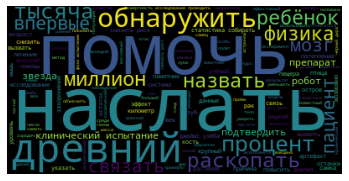

In [22]:
plt.imshow(wcloud) # создаем изображение
plt.axis("off") # выключаем оси для красоты
plt.show() # показываем график на экран

Доработаем полученное облако, используя возможности `matplotlib`.

Функция `subplots()` создает два объекта:

* «рамка» для картинки (обычно сохраняется в переменную `fig`);
* поле с осями, внутри которого строится график (обычно сохраняется в переменную `ax`).

Неформально, создавая `fig` мы резервируем место под картинку соответствующего размера, а затем проводим различные манипуляции с `ax`, чтобы внутри этого поля для картинки построить график, настроить подписи, оси и прочее. Соответственно, к `ax` мы будем применять различные методы, а по завершении работы сможем выгрузить объект `fig` в файл PNG, JPEG или PDF. Вообще функция `subplots()`, как следует из её названия, может использоваться для построения сразу нескольких графиков, но у нас пока внутри `fig` будет один.

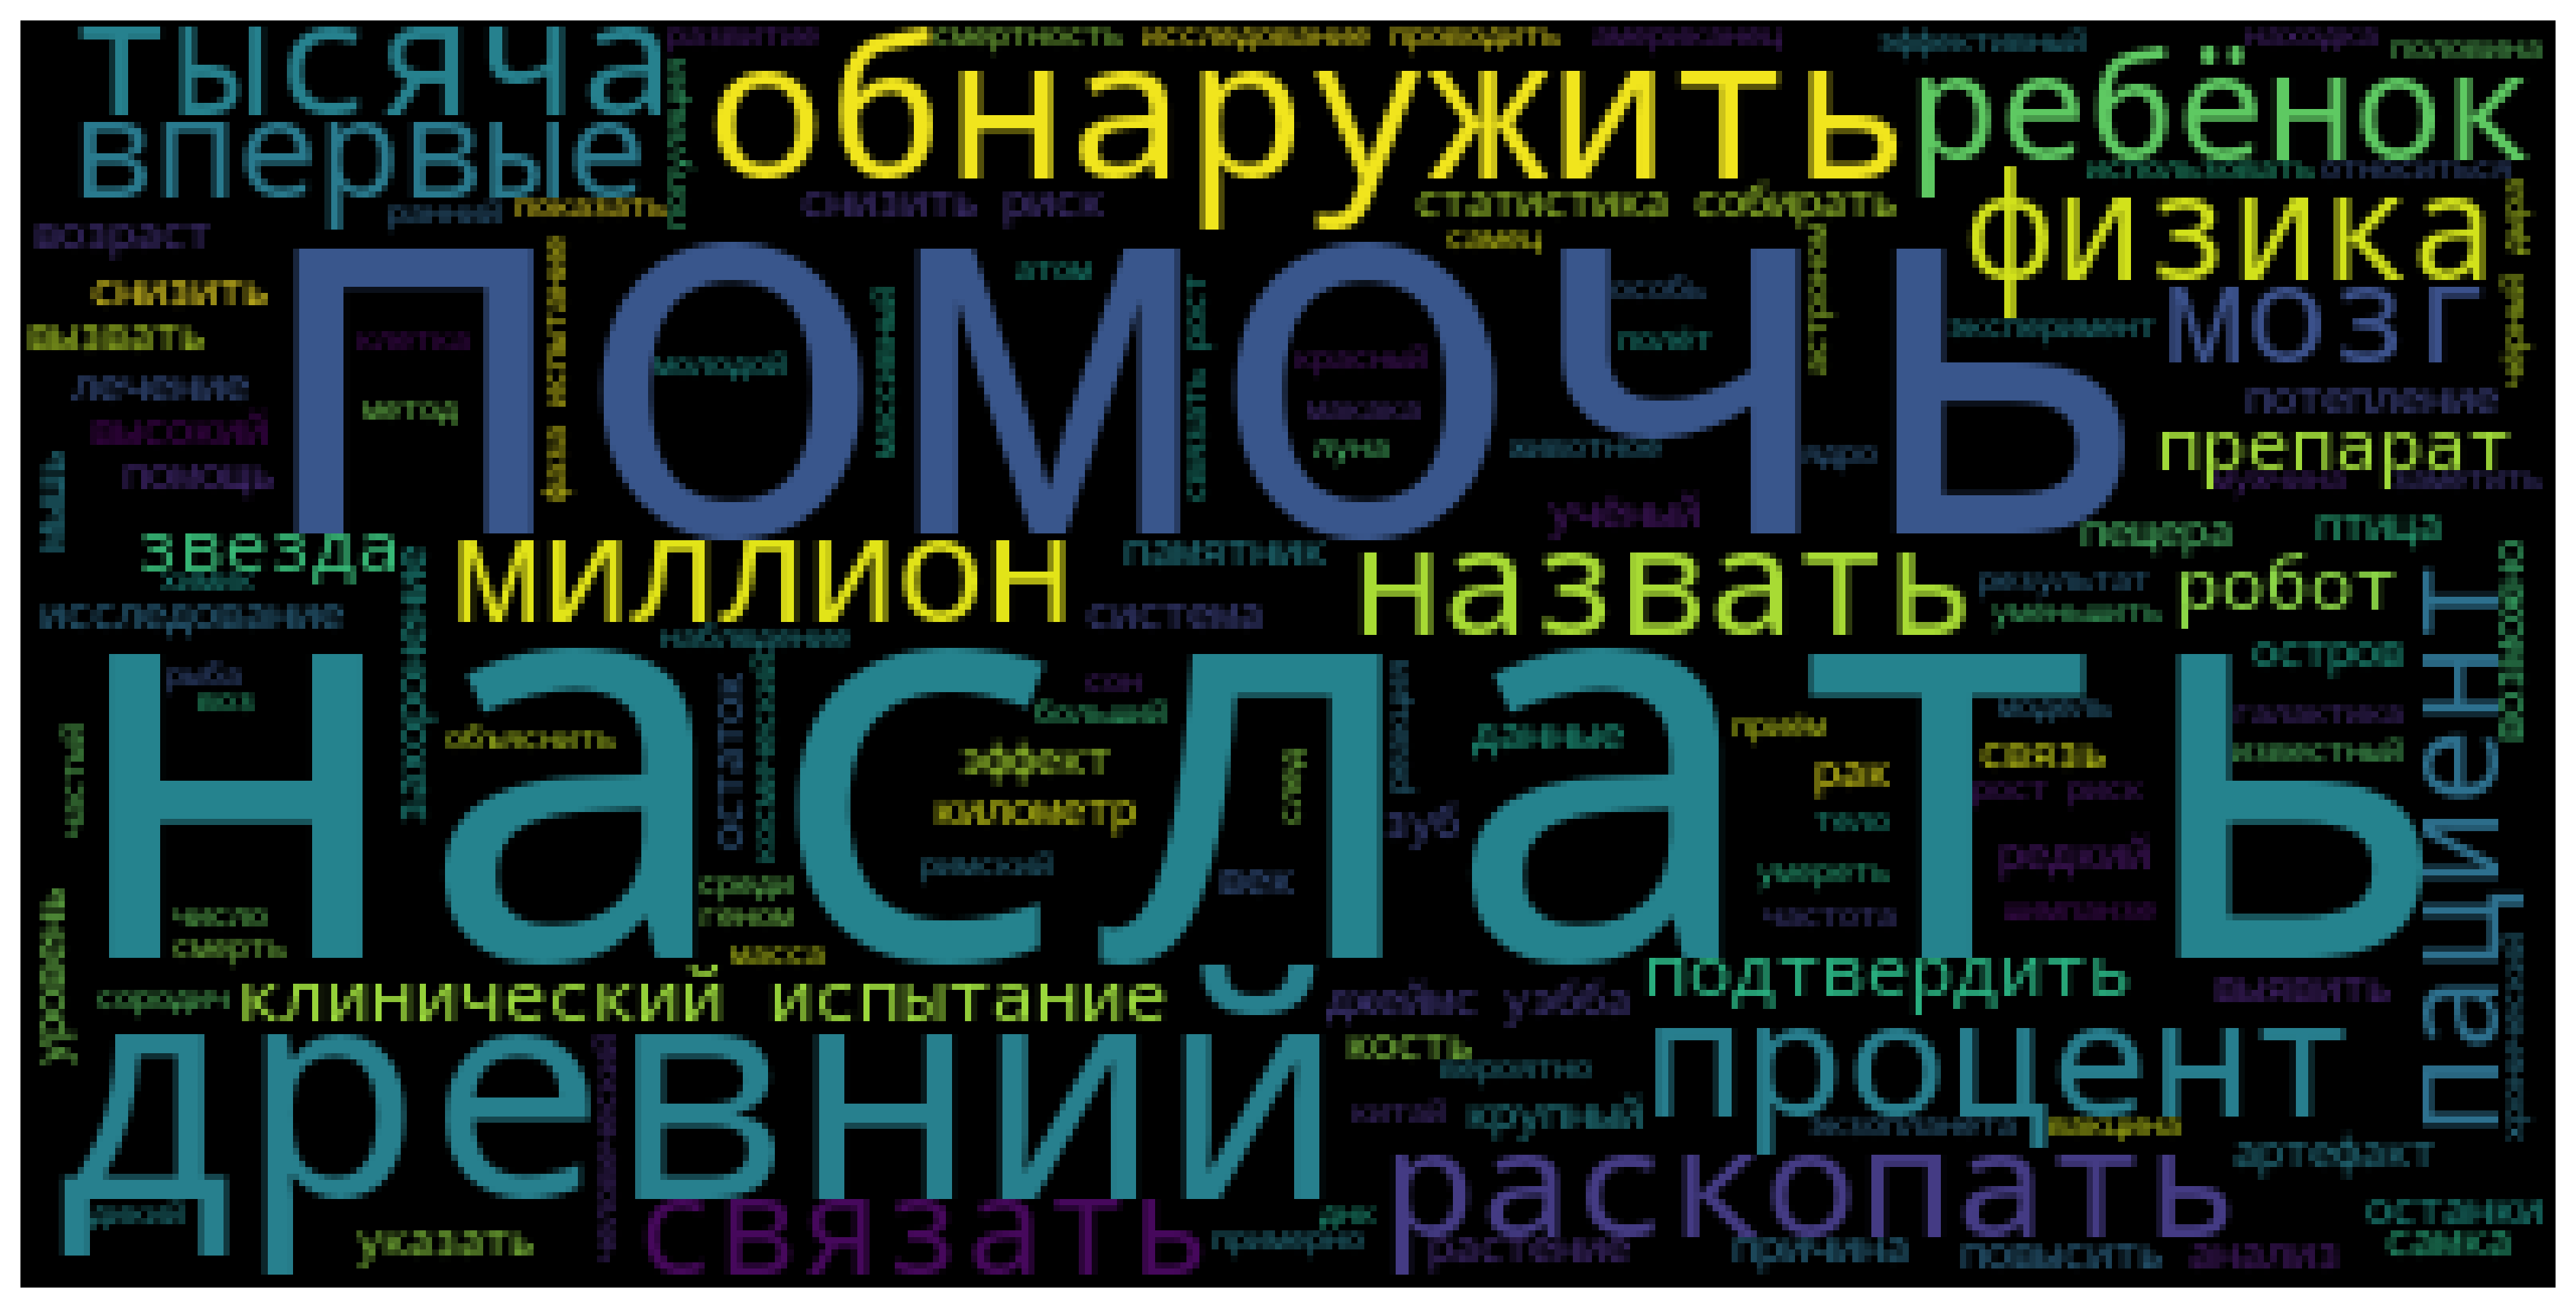

In [23]:
# figsize - размер в дюймах, делаем 16 на 9
# dpi, от dots per inch – разрешение 300 точек на дюйм (это хорошо даже для печати)

fig, ax = plt.subplots(figsize = (16, 9), dpi = 300);
ax.imshow(wcloud);
ax.axis("off");

Разрешение в итоге получилось не очень хорошим, нужно синхронизировать размер облака в `WordCloud()` и `subplots()`. В `WordCloud()` можно добавить ширину и высоту изображения с облаком (в пикселях), чтобы оно было побольше (по умолчанию 400 на 200):

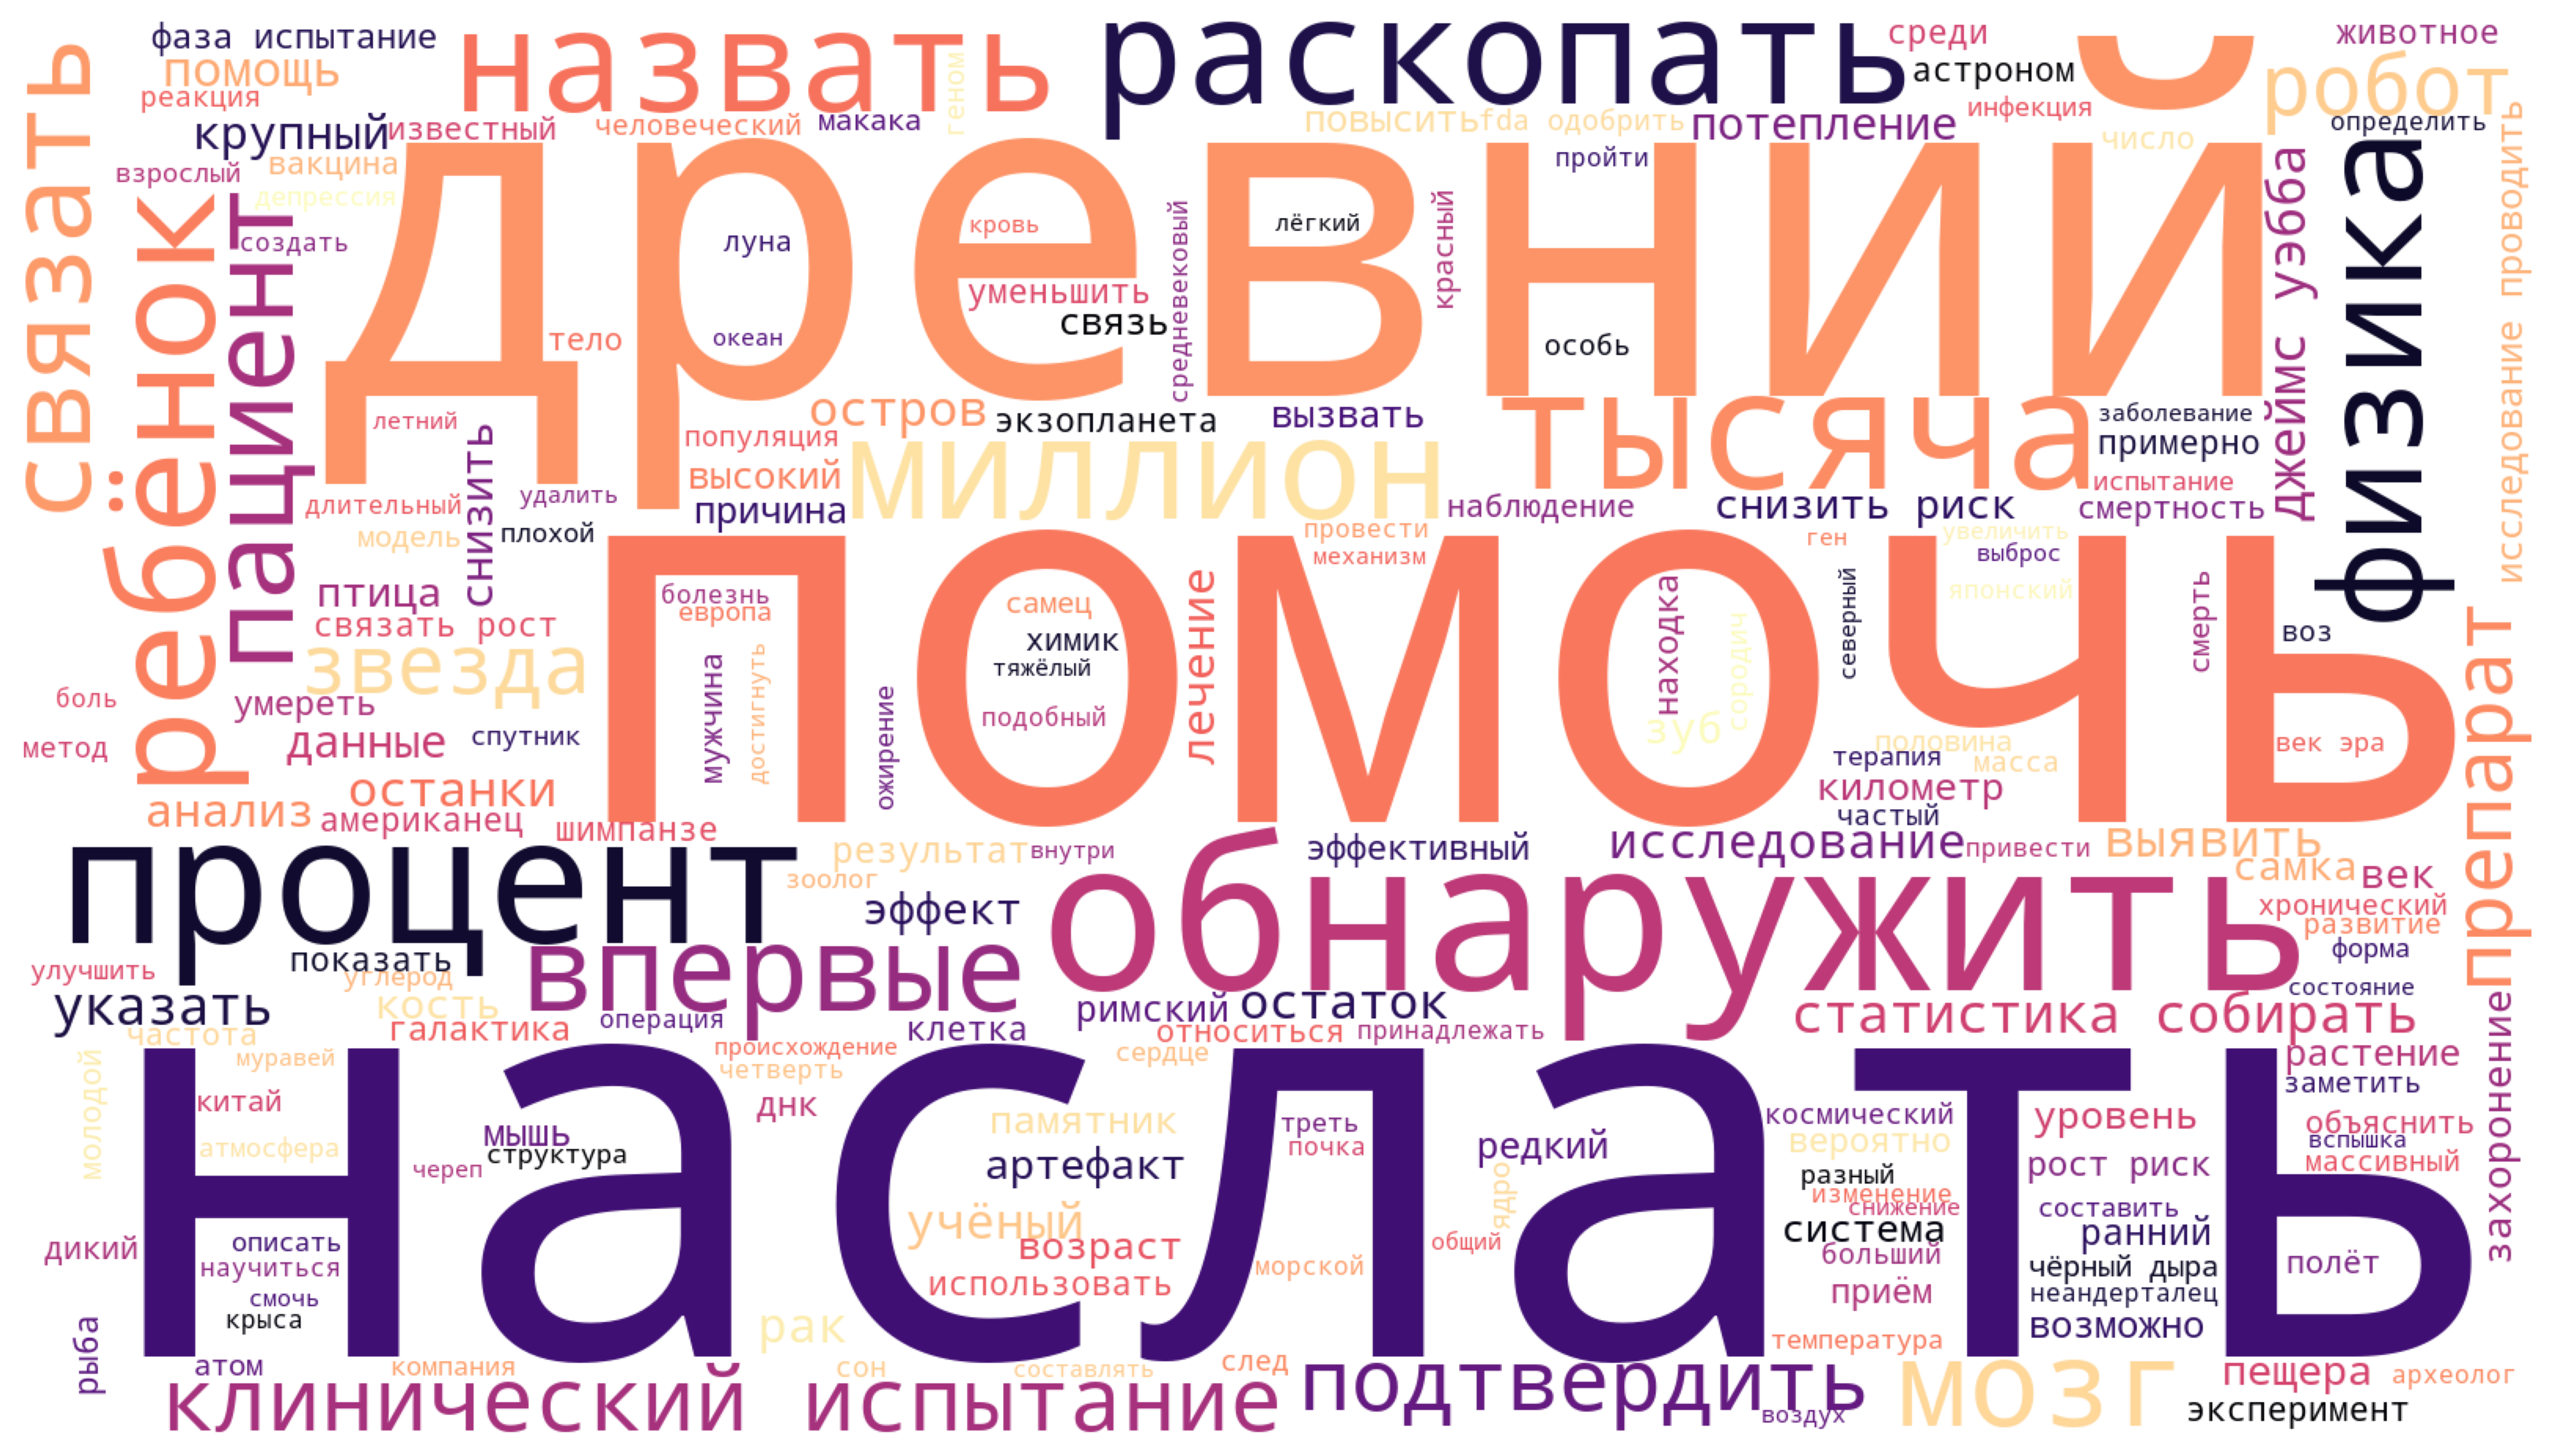

In [24]:
# width и height
# плюс, поменяем цвет фона в background_color,
# и еще палитру цветов colormap

wcloud = WordCloud(width = 1600, height = 900, 
                   background_color = "white",
                   colormap = 'magma').generate(text_clean)

fig, ax = plt.subplots(figsize = (16, 9), dpi = 300)
ax.imshow(wcloud)
ax.axis("off")

# можем сохранить картинку в файл png
# будет рядом с текущим ipynb

fig.savefig("wordcloud.png")

В качестве основы для облака слов можно взять изображение. Мы возьмём изображение с колбой (скачать [здесь](https://github.com/allatambov/PyDat25/blob/main/lab.png)). Импортируем набор функций для обработки изображения из библиотеки `PIL` (*Python Imaging Library*) и библиотеку `numpy`, чтобы потом преобразовать изображение в числовой массив:

In [25]:
import numpy as np
from PIL import Image

Загрузим изображение `lab.png`через *Upload* в Jupyter Notebook, считаем его и преобразуем в массив:

In [26]:
# каждый пиксель в формате RGB (код цвета Reg-Green-Blue) 
# или в формате RGBA (код цвета Reg-Green-Blue + непрозрачность alpha)

# здесь изображение 964 на 1074 пикселей, 
# формат RGBA, так как 4 элемента цвета для каждого пикселя

my_mask = np.array(Image.open("lab.png"))
print("Размерность массива: ", my_mask.shape)
print("Ширина изображения в пикселях: ", my_mask.shape[1])
print("Высота изображения в пикселях: ", my_mask.shape[0])
print("Число цветов для описания одного пикселя: ", my_mask.shape[2])
print(my_mask[0:2])

Размерность массива:  (1074, 964, 4)
Ширина изображения в пикселях:  964
Высота изображения в пикселях:  1074
Число цветов для описания одного пикселя:  4
[[[255 255 255 255]
  [255 255 255 255]
  [255 255 255 255]
  ...
  [255 255 255 255]
  [255 255 255 255]
  [255 255 255 255]]

 [[255 255 255 255]
  [255 255 255 255]
  [255 255 255 255]
  ...
  [255 255 255 255]
  [255 255 255 255]
  [255 255 255 255]]]


Чтобы облако по размеру подходило маске с изображением, нужно сделать так, чтобы ширина облака `width` совпадала с шириной изображения, а высота `height` – с высотой изображения. Пользуясь сведениями, полученными выше из `.shape`, сформируем новое облако:

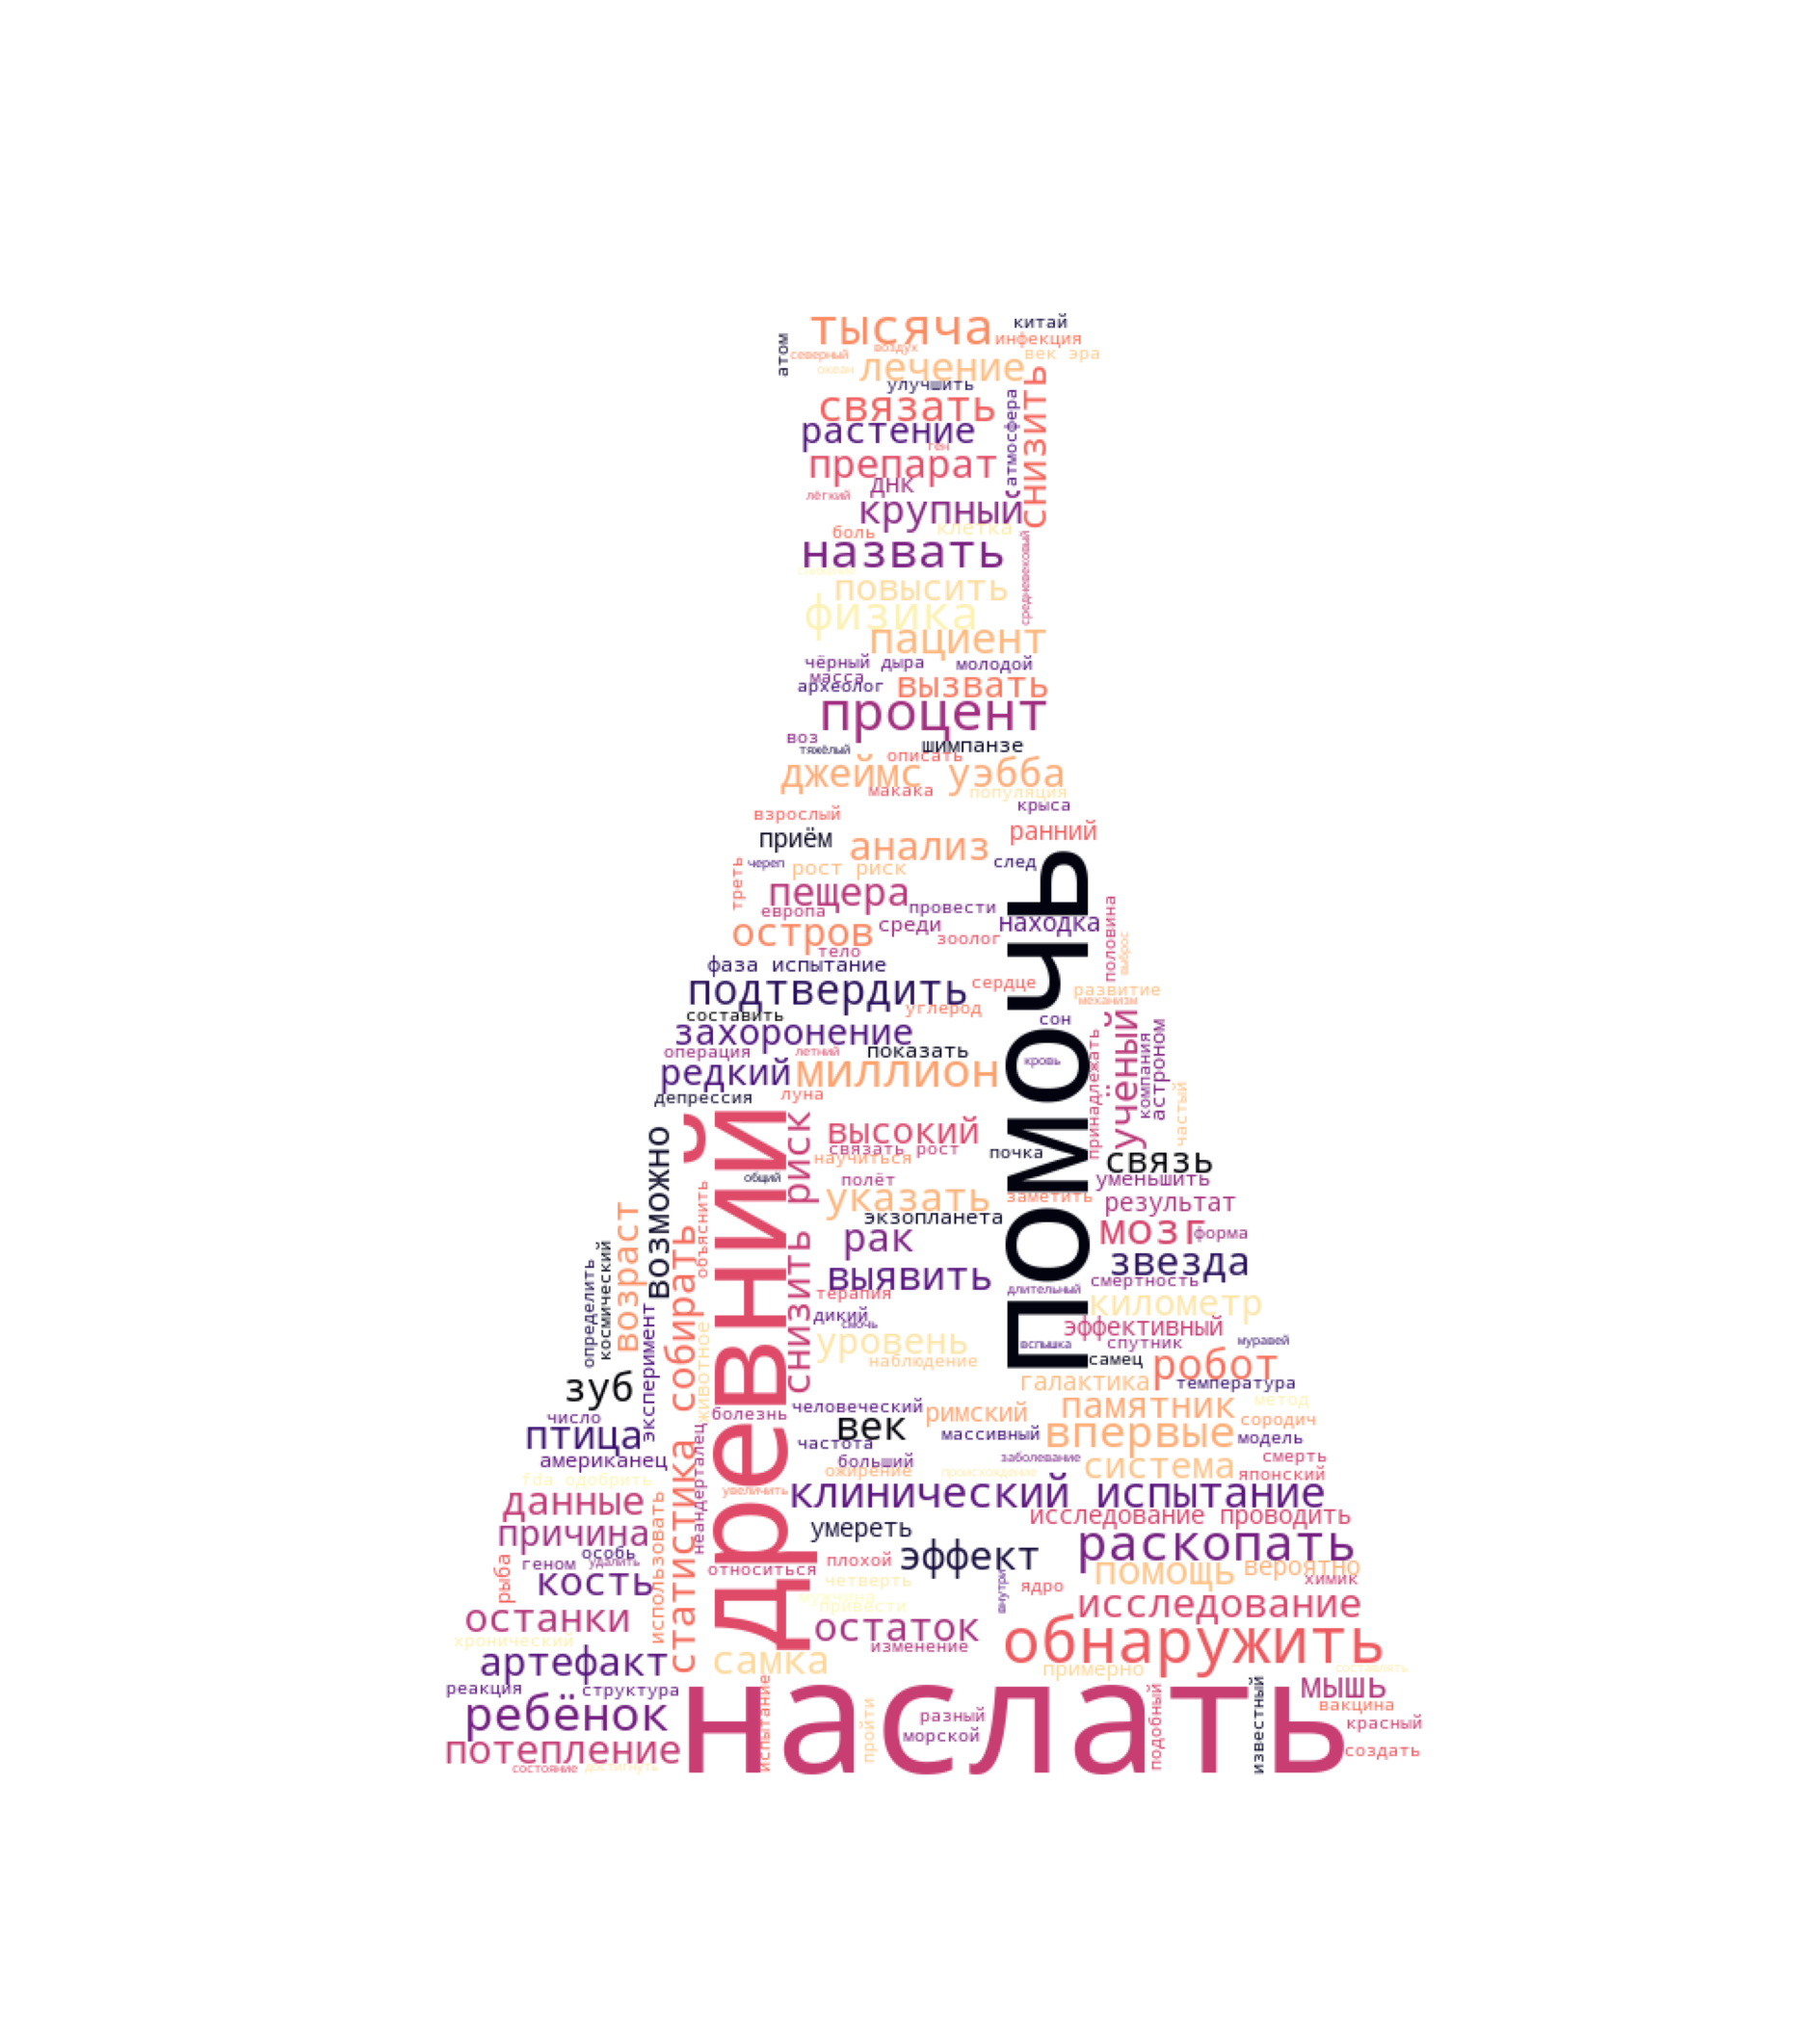

In [27]:
fig, ax = plt.subplots(figsize = (16, 9), dpi = 300);

# randomm_state – для воспроизводимости, так как слова
# по облаку раскидываются случайно

new_cloud = WordCloud(width = my_mask.shape[1], 
                      height = my_mask.shape[0], 
                      mask = my_mask, background_color = "white",
                      colormap = "magma",
                      random_state = 42).generate(text_clean)

ax.imshow(new_cloud)
ax.axis('off')

fig.savefig("new_cloud.png")